In [ ]:
%reload_ext autoreload
%autoreload 2

from torch_geometric.loader import DataLoader
from src import Crystals
# from src.models import MDNet

In [2]:
dataset = Crystals("data/processed/v8.pt")
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
dataloader = list(iter(dataloader))

In [3]:
dataloader[0]

DataBatch(x=[932, 8], edge_index=[2, 13398], pos=[932, 3], element=[64], z=[932], dist=[13398], y=[64, 266], mineral=[64], cond_vec=[64, 7], ram_fact=[64], cell_params=[64, 6], folds=[64, 4], ir_y=[64, 266], ir_fact=[64], has_ir=[64], wl=[64], batch=[932], ptr=[65])

In [11]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

In [4]:
len(dataloader)

347

In [6]:
print(dataloader[0].cell_params[0])

tensor([ 5.1890,  8.9960, 20.0960, 90.0000, 95.1800, 90.0000])


In [82]:
import random
i = random.randint(0, len(dataloader)-1)
print(i)
set(dataloader[i].has_ir.tolist())

64


{0.0, 1.0}

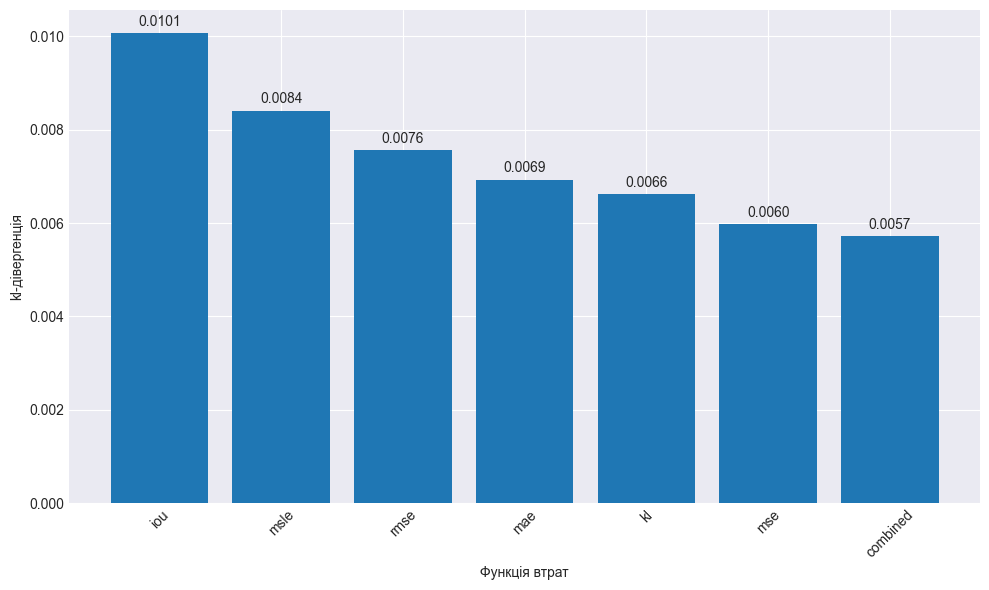

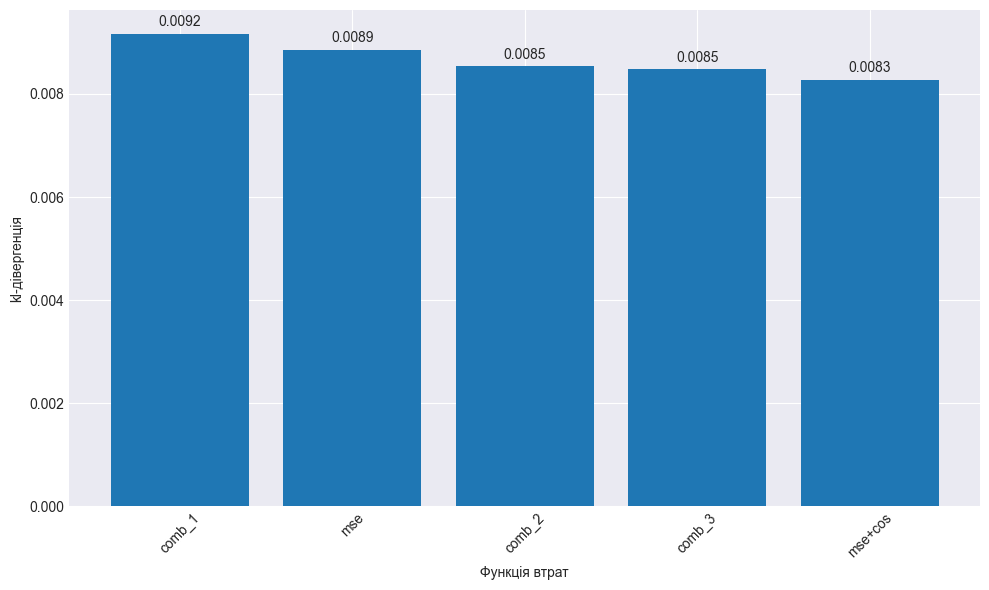

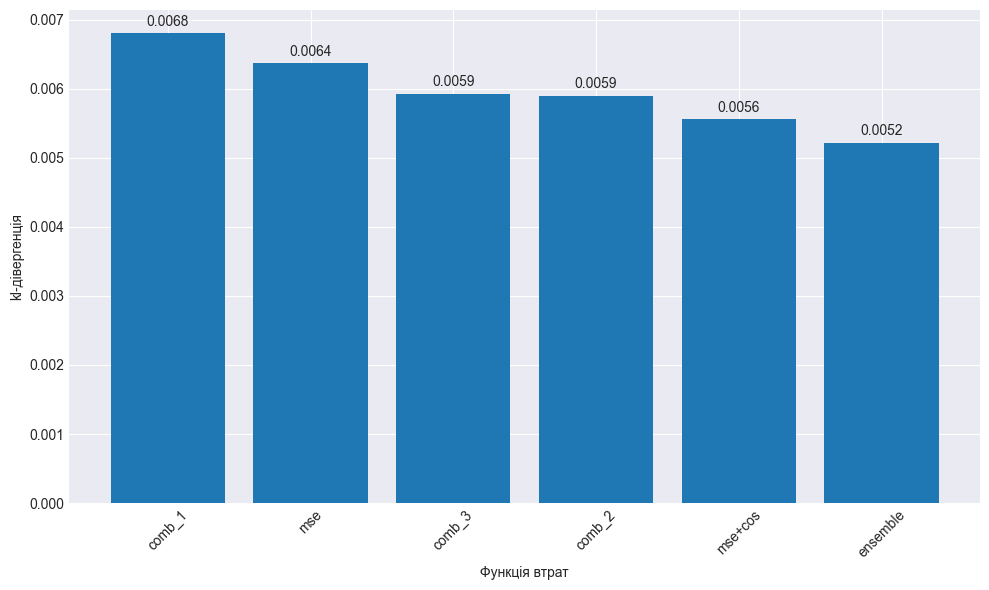

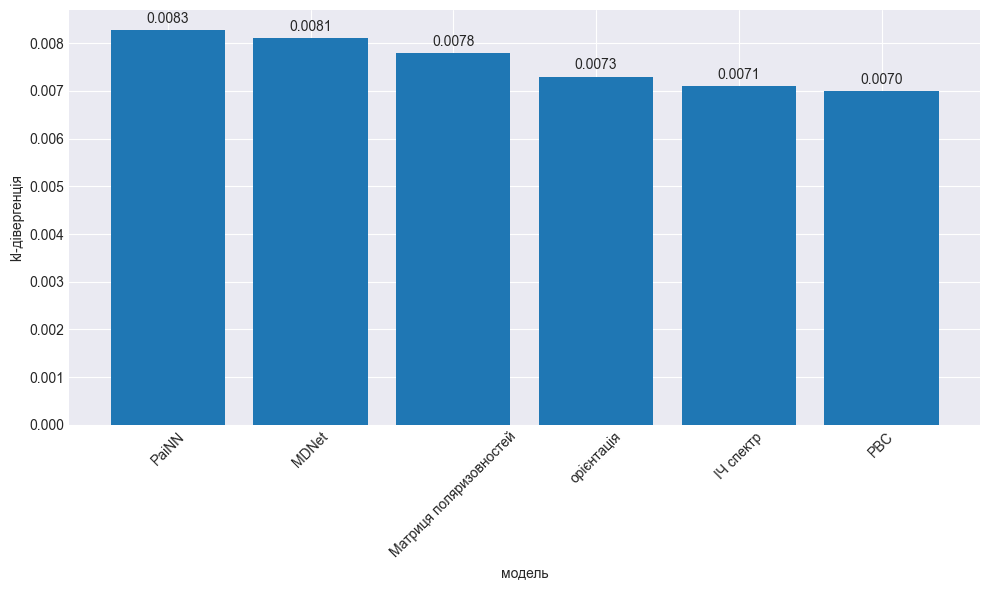

In [10]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

def create_bar_chart(data, xlabel='Функція втрат'):
    sorted_data = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(list(sorted_data.keys()), list(sorted_data.values()), color='tab:blue')
    
    ax.bar_label(bars, fmt='%.4f', padding=3)
    
    # plt.title(title)
    plt.ylabel('kl-дівергенція')
    plt.xlabel(xlabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # plt.savefig(filename)
    plt.show()
    plt.close()

data_2_2 = {
    'mse': 0.00598,
    'mae': 0.00693,
    'msle': 0.00841,
    'rmse': 0.00756,
    'iou': 0.01006,
    'kl': 0.00662,
    'combined': 0.00572
}
create_bar_chart(data_2_2)

data_2_3 = {
    'mse': 0.00886,
    'comb_3': 0.00848,
    'comb_1': 0.00917,
    'comb_2': 0.00854,
    'mse+cos': 0.00828
}
create_bar_chart(data_2_3)

data_2_4 = {
    'mse': 0.00637,
    'comb_3': 0.00593,
    'comb_1': 0.00680,
    'comb_2': 0.00590,
    'mse+cos': 0.00556,
    'ensemble': 0.00522
}
create_bar_chart(data_2_4)

data_2_5 = {
    'PaiNN': 0.00828,
    'MDNet': 0.0081,
    'Матриця поляризовностей': 0.0078,
    'орієнтація': 0.0073,
    'ІЧ спектр': 0.0071,
    'PBC': 0.0070
}
create_bar_chart(data_2_5, 'модель')

154 52


/tmp/ipykernel_149852/2135449341.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


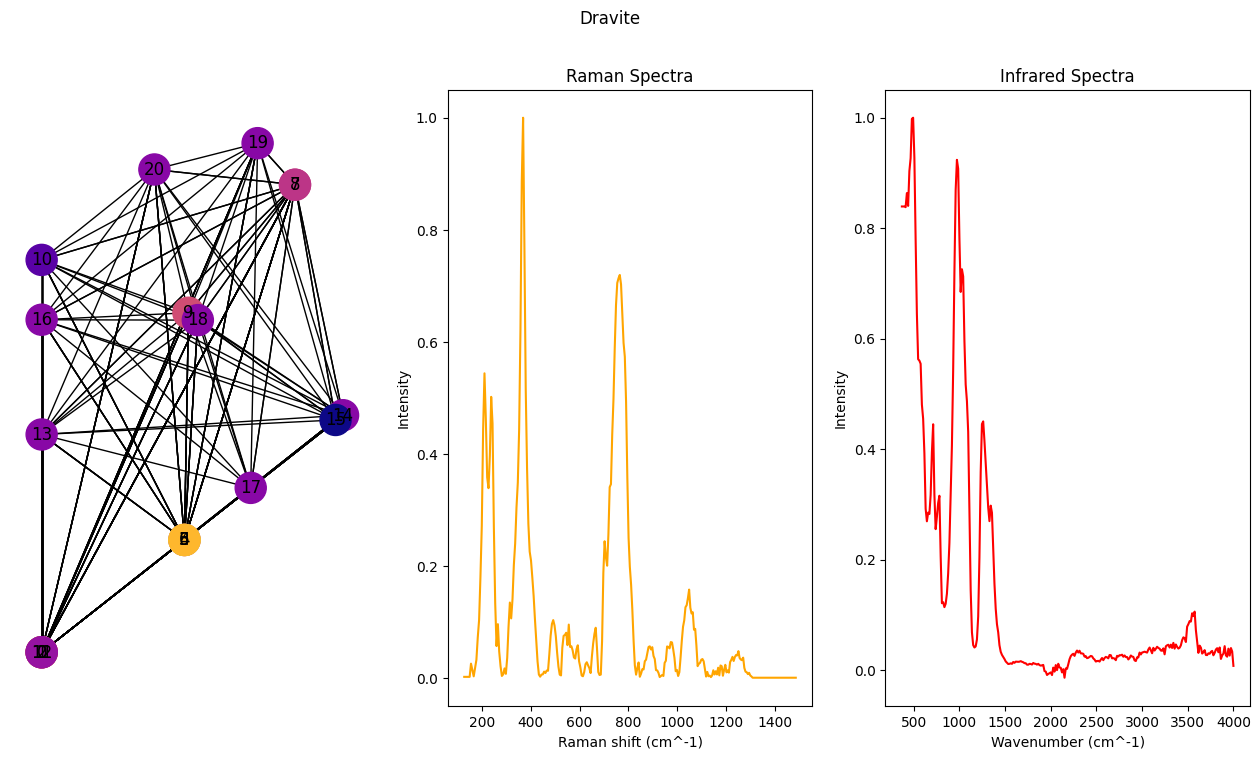

In [10]:
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from torch_geometric.utils import to_networkx

from config import wavenumbers, ir_wavenumbers

i = random.randint(0, len(dataloader)-1)
j = random.randint(0, 63)
print(i, j)
G = to_networkx(dataloader[i][j], node_attrs=['z', 'pos'], to_undirected=True)

# Plotting the X-Y plane (Looking down the laser beam)
pos_2d = {a: d['pos'][:2] for a, d in G.nodes(data=True)}

fig, ax = plt.subplots(1,3,figsize=(16, 8))
nx.draw(G, pos_2d, node_color=[d['z'] for i, d in G.nodes(data=True)], 
        with_labels=True, node_size=500, cmap=plt.cm.plasma, ax=ax[0])
ax[1].plot(wavenumbers, dataloader[i][j].y[0], c="orange")
ax[1].set_ylabel('Intensity')
ax[1].set_xlabel('Raman shift (cm^-1)')
ax[1].set_title("Raman Spectra")
ax[2].plot(ir_wavenumbers, dataloader[i][j].ir_y[0], c="red")
ax[2].set_ylabel('Intensity')
ax[2].set_xlabel('Wavenumber (cm^-1)')
ax[2].set_title("Infrared Spectra")
fig.suptitle(dataloader[i][j].mineral)
fig.show()

In [17]:
from src.models_md import MDNet2
from utils import load_model, VersionFromName
from utils.loss import MultiTaskLoss, CombLoss
from config import wavenumbers, ir_wavenumbers
from utils import loss_fn_dict


losses = ["mse", "cossim"]
loss_fn = CombLoss(*[(1, loss_fn_dict[loss]) for loss in losses])
loss_fn = MultiTaskLoss(loss_fn)
loss_name = str(loss_fn)
model_name = "MDNet2_5.47M_0.0071_best.pt"
version = VersionFromName(model_name, loss_name=loss_name)
model = load_model(model_version=version, model_name=model_name, device="cpu")
# model.load_state_dict("results/models/MDNet2_multi_1mse_1cossim/")

model.n_params()


5470231

5.14


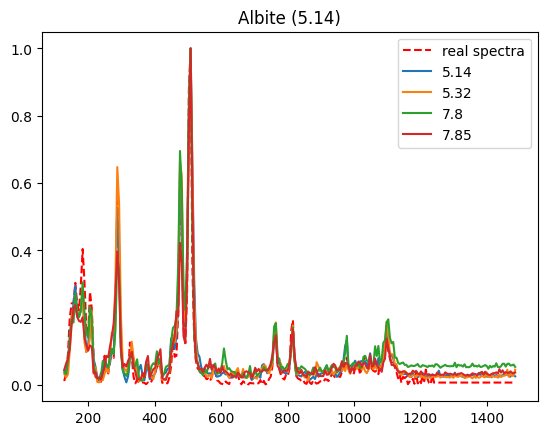

In [ ]:
import matplotlib.pyplot as plt
import copy


i = 0
j = 9
data = dataloader[i][j]
print(wl := round(data.wl.item(), 2))
datas = []
for i in [5.14, 5.32, 7.8, 7.85]:
    d = copy.deepcopy(data)
    d.wl = torch.tensor(i)
    datas.append(d)
plt.plot(wavenumbers, data.y[0], "--", label="real spectra", c="red")    
for d in datas:
    current_wl = round(d.wl.item(), 2)
    pred = model(data)["raman"].detach()[0]
    plt.plot(wavenumbers, pred.numpy(), label=f"{current_wl}")
plt.title(f"{data.mineral} ({wl})")
plt.legend()

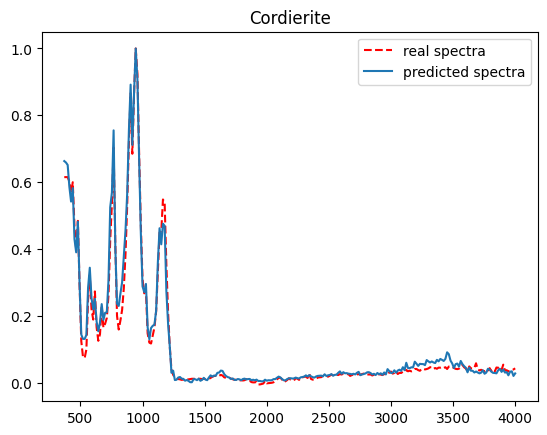

In [68]:
import random
i = 0
j = random.randint(0,63)
data = dataloader[i][j]
# print(wl := round(data.wl.item(), 2))
datas = []
pred = model(data, True)["ir"].detach()[0]
plt.plot(ir_wavenumbers, data.ir_y[0], "--", label="real spectra", c="red")    
plt.plot(ir_wavenumbers, pred.numpy(), label="predicted spectra")
plt.title(f"{data.mineral}")
plt.legend()